
# Порівняння часових рядів ABM з авторегресійними моделями

Цей Notebook аналізує дані експерименту **E4 statistical forecasting benchmark**, згенеровані в NetLogo BehaviorSpace.

## Мета

Перевірити, наскільки статистичні моделі часових рядів, навчені на фазах `baseline` і `reward`, здатні прогнозувати агреговану поведінку агентів у фазі `withdrawal`.

Порівнюються:

1. **Naive** — прогноз дорівнює останньому значенню навчальної вибірки;
2. **AR(p)** — авторегресія лише за попередніми значеннями `choice_rate`;
3. **ARX(p)** — авторегресія із зовнішнім фактором `effective_reward`.

Тестова траєкторія є синтетичною «істиною», сформованою ABM. Тому експеримент не доводить перевагу ABM над статистичними методами на реальних даних. Він показує, наскільки агреговану динаміку ABM можна відтворити без явного моделювання прихованих станів агентів — звички та внутрішньої мотивації.


In [46]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")
# sns.set_theme(style="whitegrid")
sns.set_theme()

# DATA_CANDIDATES = [
#     Path("./experiments/e4-postbonus-forecast/table.csv"),
#     Path("/mnt/data/table(2).csv"),
# ]

# DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
# if DATA_PATH is None:
#     raise FileNotFoundError(
#         "CSV не знайдено. Покладіть table(2).csv поруч із Notebook "
#         "або змініть DATA_CANDIDATES."
#     )

DATA_PATH = Path("./experiments/e4-postbonus-forecast/table.csv")



## 1. Завантаження та очищення даних

BehaviorSpace додає службові рядки перед заголовком таблиці. Функція нижче автоматично знаходить рядок, що починається з `[run number]`.


In [47]:

def read_behaviorspace_csv(path: Path) -> pd.DataFrame:
    with path.open("r", encoding="utf-8-sig", errors="replace") as f:
        lines = f.readlines()

    header_idx = None
    for idx, line in enumerate(lines):
        if "[run number]" in line:
            header_idx = idx
            break

    if header_idx is None:
        raise ValueError("Не знайдено заголовок BehaviorSpace '[run number]'.")

    return pd.read_csv(path, skiprows=header_idx)


# raw = read_behaviorspace_csv(DATA_PATH)
raw = pd.read_csv(DATA_PATH, skiprows=6)
print("Розмір первинної таблиці:", raw.shape)
raw.head()


Розмір первинної таблиці: (17190, 19)


,[run number],number-of-shoppers,reward-cycles,reward-duration,withdrawal-duration,low-reward-salience,high-reward-salience,[step],current-phase,reward-active?,"current-choice-rate ""control""","current-choice-rate ""low-salience""","current-choice-rate ""high-salience""","mean-habit ""control""","mean-habit ""low-salience""","mean-habit ""high-salience""","mean-intrinsic-motivation ""control""","mean-intrinsic-motivation ""low-salience""","mean-intrinsic-motivation ""high-salience"""
0,7,1000,1,80,80,0.1500,0.5500,0,baseline,False,0.0000,0.0000,0.0000,0.1975,0.2060,0.2045,0.4846,0.5167,0.4940
1,3,1000,1,80,80,0.1500,0.5500,0,baseline,False,0.0000,0.0000,0.0000,0.1867,0.2042,0.2089,0.5013,0.5057,0.5102
2,8,1000,1,80,80,0.1500,0.5500,0,baseline,False,0.0000,0.0000,0.0000,0.1951,0.2012,0.2012,0.5046,0.4953,0.5032
3,9,1000,1,80,80,0.1500,0.5500,0,baseline,False,0.0000,0.0000,0.0000,0.2133,0.2014,0.1901,0.4915,0.4888,0.5175
4,4,1000,1,80,80,0.1500,0.5500,0,baseline,False,0.0000,0.0000,0.0000,0.2067,0.1998,0.2048,0.4964,0.5072,0.5006


In [48]:

COLUMN_MAP = {
    "[run number]": "run",
    "[step]": "tick",
    "high-reward-salience": "salience",
    "reward-active?": "reward_active",
    "current-phase": "phase",
    'current-choice-rate "control"': "choice_control",
    'current-choice-rate "low-salience"': "choice_low",
    'current-choice-rate "high-salience"': "choice_high",
    'mean-habit "control"': "habit_control",
    'mean-habit "low-salience"': "habit_low",
    'mean-habit "high-salience"': "habit_high",
    'mean-intrinsic-motivation "control"': "motivation_control",
    'mean-intrinsic-motivation "low-salience"': "motivation_low",
    'mean-intrinsic-motivation "high-salience"': "motivation_high",
}

df = raw.rename(columns=COLUMN_MAP).copy()

required = [
    "run", "tick", "salience", "phase", "reward_active",
    "choice_high", "habit_high", "motivation_high"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"У CSV відсутні потрібні колонки: {missing}")

df["reward_active"] = (
    df["reward_active"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"true": 1, "false": 0})
)

numeric_cols = [
    "run", "tick", "salience",
    "choice_high", "habit_high", "motivation_high"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["effective_reward"] = df["reward_active"] * df["salience"]
df = df.sort_values(["salience", "run", "tick"]).reset_index(drop=True)

print("Кількість запусків:", df["run"].nunique())
print("Рівні винагороди:", sorted(df["salience"].dropna().unique()))
print("Діапазон tick:", int(df["tick"].min()), "—", int(df["tick"].max()))
print("\nКількість спостережень за фазами:")
display(df["phase"].value_counts().to_frame("rows"))


Кількість запусків: 90
Рівні винагороди: [np.float64(0.55), np.float64(0.75), np.float64(0.9)]
Діапазон tick: 0 — 190

Кількість спостережень за фазами:


,rows
phase,
reward,7200
withdrawal,7200
baseline,2790



### Примітка щодо `tick = 0`

У наданому CSV значення `current-choice-rate` на нульовому такті дорівнює нулю, оскільки агенти ще не виконали вибір. Це службове початкове спостереження, а не фактична поведінка. Для прогнозування воно вилучається, але залишається доступним у первинній таблиці `df`.


In [49]:

model_df = df[df["tick"] > 0].copy()

checks = (
    model_df.groupby(["salience", "run"])
    .agg(
        n_ticks=("tick", "size"),
        first_tick=("tick", "min"),
        last_tick=("tick", "max"),
        phases=("phase", lambda s: tuple(pd.unique(s)))
    )
)

display(checks.head())
print("Унікальні довжини траєкторій:", sorted(checks["n_ticks"].unique()))


n_ticks  first_tick  last_tick                          phases
salience run                                                                
0.5500   1        190           1        190  (baseline, reward, withdrawal)
         2        190           1        190  (baseline, reward, withdrawal)
         3        190           1        190  (baseline, reward, withdrawal)
         4        190           1        190  (baseline, reward, withdrawal)
         5        190           1        190  (baseline, reward, withdrawal)

Унікальні довжини траєкторій: [np.int64(190)]



## 2. Огляд траєкторій ABM

Графіки нижче показують середню частку цільового вибору для кожного рівня `high-reward-salience`. Вертикальні лінії позначають переходи між фазами.


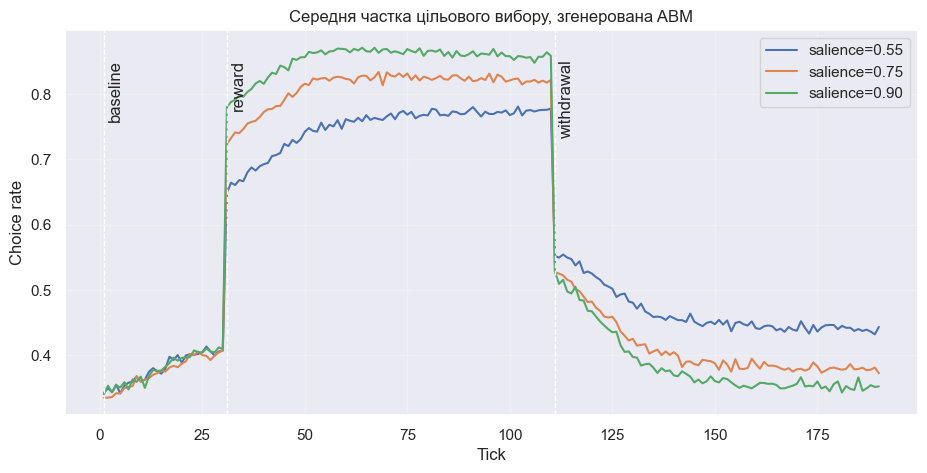

In [50]:

trajectory = (
    model_df.groupby(["salience", "tick"], as_index=False)
    .agg(
        choice_mean=("choice_high", "mean"),
        choice_sd=("choice_high", "std"),
        habit_mean=("habit_high", "mean"),
        motivation_mean=("motivation_high", "mean"),
        phase=("phase", "first"),
        reward_active=("reward_active", "first"),
    )
)

phase_starts = (
    model_df.sort_values("tick")
    .groupby("phase", as_index=False)["tick"]
    .min()
    .set_index("phase")["tick"]
    .to_dict()
)

fig, ax = plt.subplots(figsize=(11, 5))
for salience, part in trajectory.groupby("salience"):
    ax.plot(part["tick"], part["choice_mean"], label=f"salience={salience:.2f}")

for phase, tick in phase_starts.items():
    ax.axvline(tick, linestyle="--", linewidth=1)
    ax.text(tick + 1, ax.get_ylim()[1] * 0.95, phase, rotation=90, va="top")

ax.set_title("Середня частка цільового вибору, згенерована ABM")
ax.set_xlabel("Tick")
ax.set_ylabel("Choice rate")
ax.legend()
ax.grid(alpha=0.25)
plt.show()


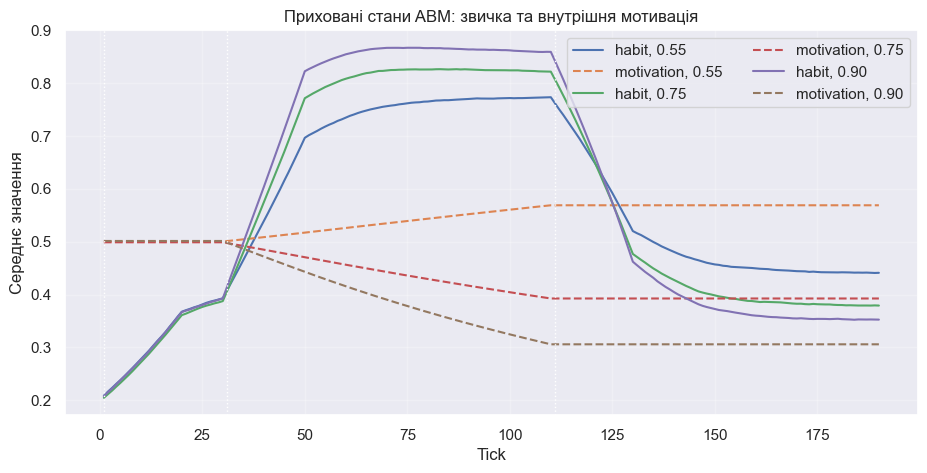

In [51]:

fig, ax = plt.subplots(figsize=(11, 5))
for salience, part in trajectory.groupby("salience"):
    ax.plot(part["tick"], part["habit_mean"], label=f"habit, {salience:.2f}")
    ax.plot(part["tick"], part["motivation_mean"], linestyle="--",
            label=f"motivation, {salience:.2f}")

for tick in phase_starts.values():
    ax.axvline(tick, linestyle=":", linewidth=1)

ax.set_title("Приховані стани ABM: звичка та внутрішня мотивація")
ax.set_xlabel("Tick")
ax.set_ylabel("Середнє значення")
ax.legend(ncol=2)
ax.grid(alpha=0.25)
plt.show()



## 3. Схема train/test

Для кожного запуску:

- **train**: фази `baseline` та `reward`;
- **test**: фаза `withdrawal`.

Такий поділ перевіряє прогноз після структурної зміни — припинення винагороди.


In [52]:

def split_train_test(run_df: pd.DataFrame):
    run_df = run_df.sort_values("tick").copy()
    train = run_df[run_df["phase"].isin(["baseline", "reward"])].copy()
    test = run_df[run_df["phase"] == "withdrawal"].copy()

    if train.empty or test.empty:
        raise ValueError("У траєкторії немає потрібних фаз train/test.")

    return train, test


example_key = model_df[["salience", "run"]].drop_duplicates().iloc[0]
example = model_df[
    (model_df["salience"] == example_key["salience"]) &
    (model_df["run"] == example_key["run"])
]
train_ex, test_ex = split_train_test(example)

print("Приклад:")
print("salience =", example_key["salience"], "run =", int(example_key["run"]))
print("train:", int(train_ex["tick"].min()), "—", int(train_ex["tick"].max()),
      f"({len(train_ex)} спостережень)")
print("test:", int(test_ex["tick"].min()), "—", int(test_ex["tick"].max()),
      f"({len(test_ex)} спостережень)")


Приклад:
salience = 0.55 run = 1
train: 1 — 110 (110 спостережень)
test: 111 — 190 (80 спостережень)



## 4. Вибір порядку авторегресії

Порядок `p` обирається окремо для кожного рівня винагороди за мінімальним AIC на **усередненій навчальній траєкторії**. Це зменшує обчислювальне навантаження й не використовує тестову фазу.


In [53]:

def select_ar_lag(train_series: pd.Series, max_lag: int = 12) -> tuple[int, pd.DataFrame]:
    records = []
    y = np.asarray(train_series, dtype=float)

    for p in range(1, max_lag + 1):
        try:
            fit = AutoReg(y, lags=p, trend="ct", old_names=False).fit()
            records.append({"lag": p, "aic": fit.aic, "bic": fit.bic})
        except Exception:
            continue

    scores = pd.DataFrame(records)
    if scores.empty:
        raise RuntimeError("Не вдалося оцінити жодну AR-модель.")

    best_p = int(scores.loc[scores["aic"].idxmin(), "lag"])
    return best_p, scores


selected_lags = {}
lag_tables = {}

for salience, part in model_df.groupby("salience"):
    mean_train = (
        part[part["phase"].isin(["baseline", "reward"])]
        .groupby("tick")["choice_high"]
        .mean()
        .sort_index()
    )
    best_p, scores = select_ar_lag(mean_train, max_lag=12)
    selected_lags[float(salience)] = best_p
    lag_tables[float(salience)] = scores

display(pd.DataFrame(
    [{"salience": k, "selected_lag": v} for k, v in selected_lags.items()]
))


,salience,selected_lag
0,0.5500,1
1,0.7500,1
2,0.9000,1



## 5. Моделі та метрики

### Моделі

- `Naive`: усі майбутні значення дорівнюють останньому `choice_rate` у train;
- `AR`: авторегресія з константою і трендом;
- `ARX`: AR-модель у просторі станів із відомим зовнішнім фактором `effective_reward`.

### Метрики

- **MAE**;
- **RMSE**;
- абсолютна похибка фінального значення;
- абсолютна похибка середнього рівня у withdrawal-фазі.

Прогнози обрізаються до інтервалу `[0, 1]`, оскільки `choice_rate` є часткою.


In [54]:

def clip_probability(x):
    return np.clip(np.asarray(x, dtype=float), 0.0, 1.0)


def forecast_naive(train_y, horizon):
    return np.repeat(float(train_y[-1]), horizon)


def forecast_ar(train_y, horizon, lag):
    model = AutoReg(
        np.asarray(train_y, dtype=float),
        lags=lag,
        trend="ct",
        old_names=False
    ).fit()
    pred = model.predict(
        start=len(train_y),
        end=len(train_y) + horizon - 1,
        dynamic=False
    )
    return clip_probability(pred)


def forecast_arx(train_y, train_x, test_x, lag):
    model = SARIMAX(
        np.asarray(train_y, dtype=float),
        exog=np.asarray(train_x, dtype=float).reshape(-1, 1),
        order=(lag, 0, 0),
        trend="ct",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=300)

    pred = model.get_forecast(
        steps=len(test_x),
        exog=np.asarray(test_x, dtype=float).reshape(-1, 1)
    ).predicted_mean

    return clip_probability(pred)


def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    return {
        "mae": mean_absolute_error(actual, predicted),
        "rmse": np.sqrt(mean_squared_error(actual, predicted)),
        "final_abs_error": abs(actual[-1] - predicted[-1]),
        "withdrawal_mean_abs_error": abs(actual.mean() - predicted.mean()),
    }



## 6. Оцінювання на кожному незалежному запуску


In [55]:

results = []
forecast_store = {}

for (salience, run), part in model_df.groupby(["salience", "run"], sort=True):
    train, test = split_train_test(part)

    train_y = train["choice_high"].to_numpy()
    test_y = test["choice_high"].to_numpy()
    train_x = train["effective_reward"].to_numpy()
    test_x = test["effective_reward"].to_numpy()

    lag = selected_lags[float(salience)]

    predictions = {
        "Naive": clip_probability(forecast_naive(train_y, len(test))),
    }

    try:
        predictions["AR"] = forecast_ar(train_y, len(test), lag)
    except Exception as exc:
        print(f"AR error: salience={salience}, run={run}: {exc}")

    try:
        predictions["ARX"] = forecast_arx(train_y, train_x, test_x, lag)
    except Exception as exc:
        print(f"ARX error: salience={salience}, run={run}: {exc}")

    for model_name, pred in predictions.items():
        metric_values = calculate_metrics(test_y, pred)
        results.append({
            "salience": float(salience),
            "run": int(run),
            "lag": int(lag),
            "model": model_name,
            **metric_values,
        })

        forecast_store[(float(salience), int(run), model_name)] = pd.DataFrame({
            "tick": test["tick"].to_numpy(),
            "actual": test_y,
            "predicted": pred,
        })

results_df = pd.DataFrame(results)
print("Кількість оцінених прогнозів:", len(results_df))
display(results_df.head())


Кількість оцінених прогнозів: 270


,salience,run,lag,model,mae,rmse,final_abs_error,withdrawal_mean_abs_error
0,0.5500,1,1,Naive,0.2863,0.2896,0.3273,0.2863
1,0.5500,1,1,AR,0.4697,0.4816,0.5646,0.4697
2,0.5500,1,1,ARX,0.4765,0.4785,0.4354,0.4765
3,0.5500,2,1,Naive,0.3212,0.3244,0.3363,0.3212
4,0.5500,2,1,AR,0.4924,0.5025,0.5495,0.4924



## 7. Підсумкове порівняння


In [56]:

summary = (
    results_df.groupby(["salience", "model"], as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_sd=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_sd=("rmse", "std"),
        final_error_mean=("final_abs_error", "mean"),
        withdrawal_mean_error=("withdrawal_mean_abs_error", "mean"),
        n=("run", "count"),
    )
    .sort_values(["salience", "rmse_mean"])
)

display(summary)


,salience,model,mae_mean,mae_sd,rmse_mean,rmse_sd,final_error_mean,withdrawal_mean_error,n
2,0.5500,Naive,0.3122,0.0227,0.3151,0.0226,0.3346,0.3122,30
1,0.5500,ARX,0.4651,0.0099,0.4670,0.0099,0.4432,0.4651,30
0,0.5500,AR,0.4883,0.0115,0.4982,0.0107,0.5568,0.4883,30
4,0.7500,ARX,0.3305,0.1045,0.3379,0.0989,0.3405,0.3300,30
5,0.7500,Naive,0.4125,0.0179,0.4156,0.0177,0.4495,0.4125,30
3,0.7500,AR,0.5577,0.0119,0.5659,0.0107,0.6277,0.5577,30
7,0.9000,ARX,0.1825,0.0986,0.1934,0.0960,0.2277,0.1763,30
8,0.9000,Naive,0.4734,0.0182,0.4766,0.0180,0.5069,0.4734,30
6,0.9000,AR,0.5940,0.0102,0.6007,0.0096,0.6479,0.5940,30


In [57]:

overall_summary = (
    results_df.groupby("model", as_index=False)
    .agg(
        mae_mean=("mae", "mean"),
        mae_sd=("mae", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_sd=("rmse", "std"),
        final_error_mean=("final_abs_error", "mean"),
        withdrawal_mean_error=("withdrawal_mean_abs_error", "mean"),
        n=("run", "count"),
    )
    .sort_values("rmse_mean")
)

display(overall_summary)


,model,mae_mean,mae_sd,rmse_mean,rmse_sd,final_error_mean,withdrawal_mean_error,n
1,ARX,0.3260,0.1422,0.3328,0.1373,0.3372,0.3238,90
2,Naive,0.3994,0.0696,0.4024,0.0697,0.4304,0.3994,90
0,AR,0.5467,0.0455,0.5549,0.0440,0.6108,0.5467,90


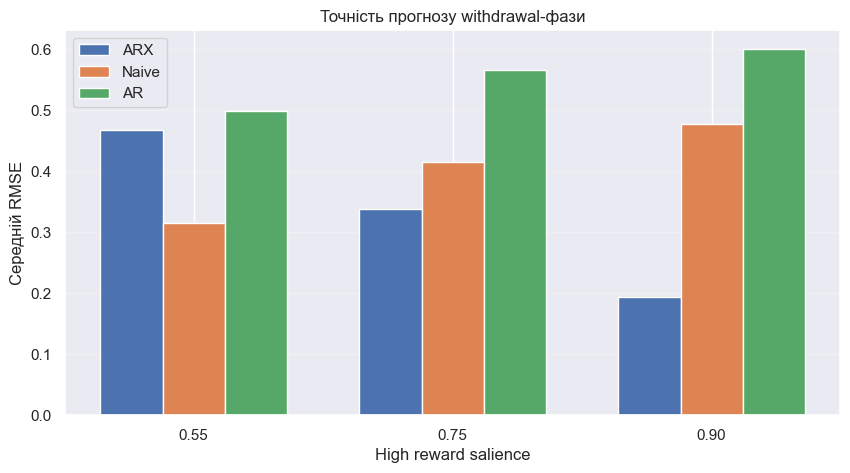

In [58]:

models = list(overall_summary["model"])
x = np.arange(len(sorted(results_df["salience"].unique())))
width = 0.24

fig, ax = plt.subplots(figsize=(10, 5))
for idx, model_name in enumerate(models):
    part = summary[summary["model"] == model_name].sort_values("salience")
    ax.bar(
        x + (idx - (len(models) - 1) / 2) * width,
        part["rmse_mean"],
        width=width,
        label=model_name
    )

ax.set_xticks(x)
ax.set_xticklabels([f"{v:.2f}" for v in sorted(results_df["salience"].unique())])
ax.set_xlabel("High reward salience")
ax.set_ylabel("Середній RMSE")
ax.set_title("Точність прогнозу withdrawal-фази")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.show()


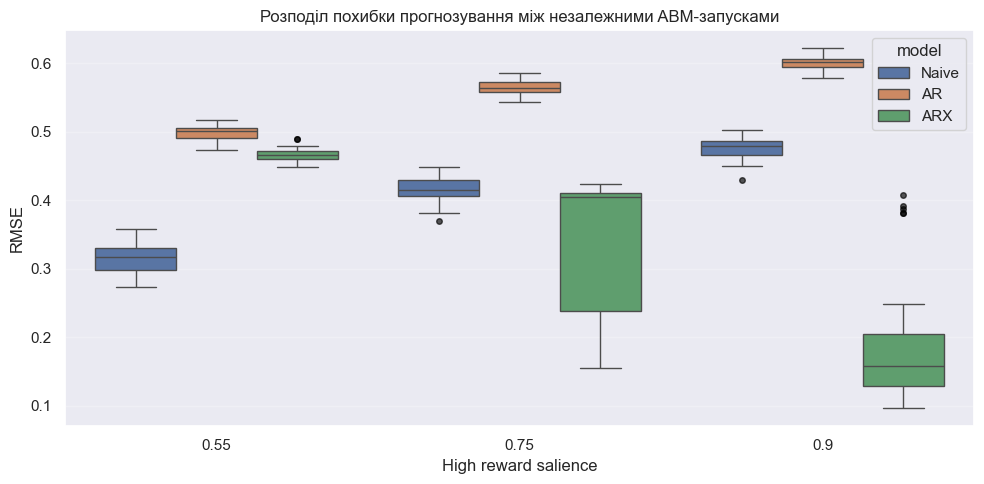

In [78]:

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=results_df,
    x="salience",
    y="rmse",
    hue="model",
    showfliers=True,
    flierprops={
        "marker": "o",
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "markersize": 4,
        "alpha": 0.65,
    },
    ax=ax,
)

ax.set_xlabel("High reward salience")
ax.set_ylabel("RMSE")
ax.set_title("Розподіл похибки прогнозування між незалежними ABM-запусками")
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()



## 8. Приклади прогнозів

Нижче показується один репрезентативний запуск для кожного рівня винагороди. Для публікації краще використовувати також графік прогнозу усередненої траєкторії.


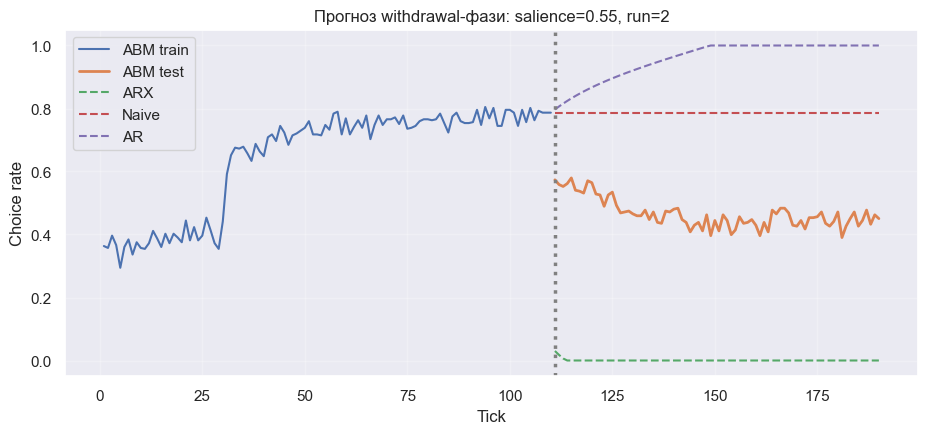

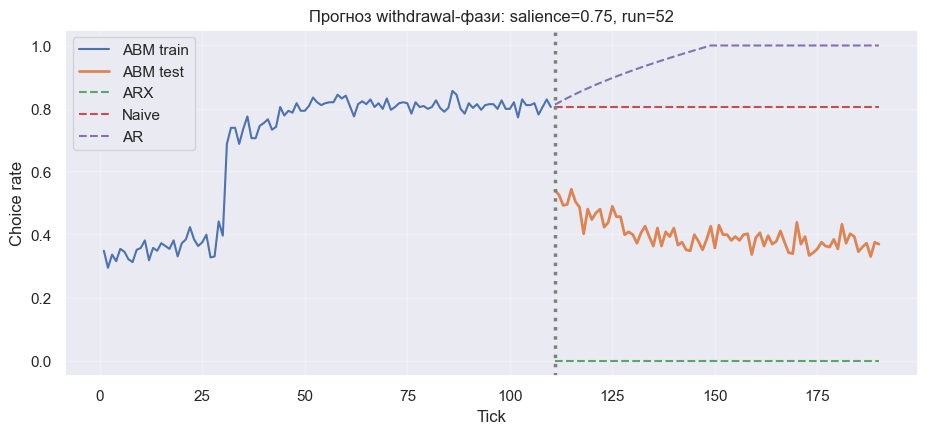

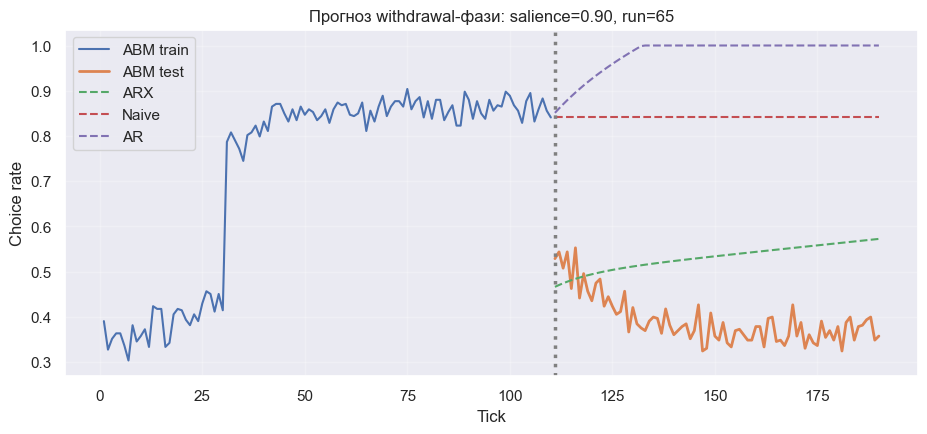

In [60]:

for salience in sorted(results_df["salience"].unique()):
    sal_part = results_df[results_df["salience"] == salience]
    preferred = "ARX" if "ARX" in sal_part["model"].unique() else "AR"
    model_part = sal_part[sal_part["model"] == preferred].copy()

    median_rmse = model_part["rmse"].median()
    example_run = int(
        model_part.iloc[(model_part["rmse"] - median_rmse).abs().argsort().iloc[0]]["run"]
    )

    full = model_df[
        (model_df["salience"] == salience) &
        (model_df["run"] == example_run)
    ].sort_values("tick")
    train, test = split_train_test(full)

    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(train["tick"], train["choice_high"], label="ABM train")
    ax.plot(test["tick"], test["choice_high"], label="ABM test", linewidth=2)

    for model_name in models:
        key = (float(salience), example_run, model_name)
        if key in forecast_store:
            f = forecast_store[key]
            ax.plot(f["tick"], f["predicted"], linestyle="--", label=model_name)

    ax.axvline(test["tick"].min(), linestyle=":", linewidth=2.5, color="gray")
    ax.set_title(
        f"Прогноз withdrawal-фази: salience={salience:.2f}, run={example_run}"
    )
    ax.set_xlabel("Tick")
    ax.set_ylabel("Choice rate")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.show()



## 9. Перевірка покращення відносно наївної моделі

Від’ємне значення `RMSE improvement` означає, що модель працює гірше за Naive. Додатне — краще.


In [61]:

pivot = results_df.pivot_table(
    index=["salience", "run"],
    columns="model",
    values="rmse"
).reset_index()

for model_name in ["AR", "ARX"]:
    if model_name in pivot.columns:
        pivot[f"{model_name}_improvement_vs_naive"] = (
            pivot["Naive"] - pivot[model_name]
        ) / pivot["Naive"]

improvement_cols = [
    c for c in pivot.columns if c.endswith("_improvement_vs_naive")
]

if improvement_cols:
    display(
        pivot.groupby("salience")[improvement_cols]
        .agg(["mean", "median", "std"])
    )
else:
    print("Немає повного набору моделей для обчислення покращення.")


model    AR_improvement_vs_naive                ARX_improvement_vs_naive  \
                            mean  median    std                     mean   
salience                                                                   
0.5500                   -0.5872 -0.5761 0.0913                  -0.4903   
0.7500                   -0.3635 -0.3655 0.0439                   0.1874   
0.9000                   -0.2617 -0.2491 0.0402                   0.5954   

model                    
          median    std  
salience                 
0.5500   -0.4759 0.1241  
0.7500    0.0667 0.2366  
0.9000    0.6599 0.1969


## 10. Автоматичний текстовий висновок


In [62]:

best_overall = overall_summary.iloc[0]

print(
    f"Найменший середній RMSE має модель {best_overall['model']} "
    f"({best_overall['rmse_mean']:.4f})."
)

for salience in sorted(summary["salience"].unique()):
    part = summary[summary["salience"] == salience].sort_values("rmse_mean")
    best = part.iloc[0]
    print(
        f"Для salience={salience:.2f} найкраща модель — "
        f"{best['model']} із RMSE={best['rmse_mean']:.4f}."
    )

print(
    "\nІнтерпретація: висока прогнозна точність AR/ARX означає, що агрегована "
    "динаміка ABM добре апроксимується часовим рядом. Низька точність після "
    "припинення винагороди вказує на структурну зміну, яку складно передбачити "
    "лише з попередніх агрегованих значень."
)


Найменший середній RMSE має модель ARX (0.3328).
Для salience=0.55 найкраща модель — Naive із RMSE=0.3151.
Для salience=0.75 найкраща модель — ARX із RMSE=0.3379.
Для salience=0.90 найкраща модель — ARX із RMSE=0.1934.

Інтерпретація: висока прогнозна точність AR/ARX означає, що агрегована динаміка ABM добре апроксимується часовим рядом. Низька точність після припинення винагороди вказує на структурну зміну, яку складно передбачити лише з попередніх агрегованих значень.



## 11. Необов’язковий пояснювальний benchmark із внутрішніми станами

Можна додати статистичну модель, яка використовує `habit_high` та `motivation_high`. Проте їхні **майбутні тестові значення** є невідомими у реальному прогнозі. Тому така модель буде не чесним forecast benchmark, а пояснювальною верхньою межею: вона показуватиме, наскільки доступ до прихованих станів ABM покращує відтворення траєкторії.

Для основного порівняння в статті рекомендовано залишити `Naive`, `AR` та `ARX`.



## 12. Обмеження експерименту

1. Дані створені самою ABM, тому ABM не оцінюється як прогнозна модель на незалежній реальності.
2. Статистична модель прогнозує агреговану частку виборів, а не індивідуальну поведінку покупців.
3. Train/test розділені зміною режиму, тому це складніший випадок, ніж прогноз усередині стабільної фази.
4. Результати залежать від реалізованих у ABM припущень щодо звички, мотивації та crowding-out.
5. Емпірична валідація потребуватиме транзакційних даних реальної програми лояльності.
